# Causalidad entre Variables Financieras con Grafos

Taller B3-T3 — Descubrimiento de estructura causal sobre variables macro (SP500, VIX, Oro, Bonos, Dolar)  
usando Grafos Acíclicos Dirigidos (DAG). Se compara correlacion simetrica vs causalidad dirigida.

## 0. Instalacion

Instala las dependencias necesarias si no estan disponibles en el entorno.

In [10]:
!pip install pgmpy yfinance networkx matplotlib pandas numpy scikit-learn seaborn lingam pyvis statsmodels --quiet


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Imports

Carga todas las librerias del proyecto. `warnings` suprime los FutureWarning de pgmpy.

In [11]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import yfinance as yf

from pgmpy.estimators import PC, HillClimbSearch
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.stattools import grangercausalitytests
import lingam
from pyvis.network import Network

## 2. Datos

Descarga precios diarios de 5 activos macro (2000-2024) y los convierte a retornos porcentuales.  
Se trabaja siempre con retornos, nunca con precios, para garantizar estacionariedad.

In [12]:
tickers = ['^GSPC', '^VIX', 'GLD', 'TLT', 'DX-Y.NYB']
names   = ['SP500', 'VIX', 'GLD', 'TLT', 'DXY']

raw = yf.download(tickers, start='2000-01-01', end='2024-12-31', auto_adjust=True)['Close']
raw.columns = names
returns = raw.pct_change().dropna()
print(returns.shape, '\n', returns.head(3))

[*********************100%***********************]  5 of 5 completed

(5069, 5) 
                SP500       VIX       GLD       TLT       DXY
Date                                                        
2004-11-19 -0.004541  0.009013 -0.007980 -0.011161  0.040062
2004-11-22 -0.001440  0.003796  0.005211  0.005896 -0.039259
2004-11-23 -0.002645 -0.004449  0.001240 -0.000255 -0.023130


## 3. Correlacion de Pearson — matriz simetrica

La correlacion mide asociacion lineal pero es **simetrica**: `corr(A,B) == corr(B,A)`.  
No hay flechas ni direccion — no dice quien causa a quien.

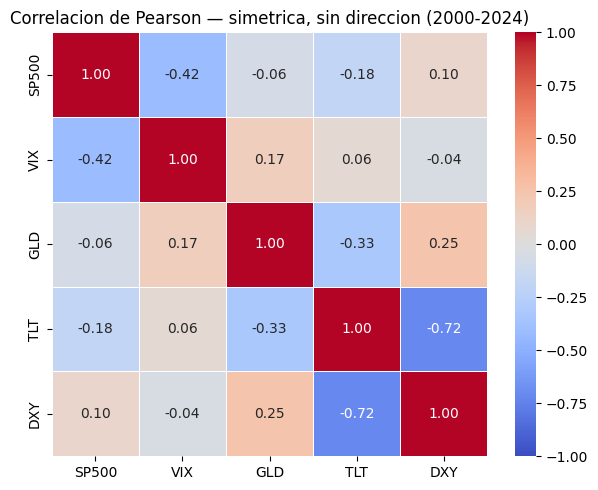

In [13]:
corr = returns.corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Correlacion de Pearson — simetrica, sin direccion (2000-2024)')
plt.tight_layout()
plt.show()

## 4. DAG — Algoritmo PC (datos completos)

El algoritmo PC elimina aristas donde detecta independencia condicional (`pearsonr`)  
y orienta colisionadores. Produce un CPDAG — grafo parcialmente dirigido.

In [14]:
est_pc = PC(data=returns)
dag_pc = est_pc.estimate(variant='stable', ci_test='pearsonr', significance_level=0.05)
print('Aristas PC:', list(dag_pc.edges()))

Working for n conditional variables: 4: 100%|██████████| 5/5 [00:00<00:00, 54.13it/s] 

Aristas PC: [('SP500', 'VIX'), ('SP500', 'DXY'), ('SP500', 'TLT'), ('VIX', 'GLD'), ('VIX', 'SP500'), ('DXY', 'SP500'), ('DXY', 'TLT'), ('TLT', 'DXY')]


## 5. Visualizacion: grafo dirigido y matriz de adyacencia

Se muestra el DAG con flechas (networkx) y como matriz numerica asimetrica.  
`adj[i,j]=1` significa arista `i -> j`. La asimetria contrasta con la matriz de Pearson.

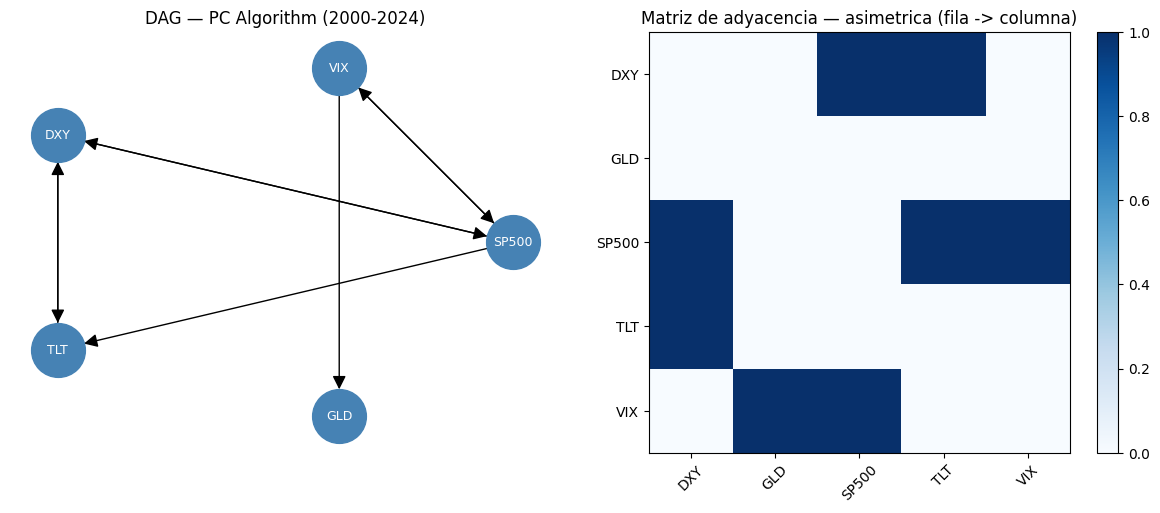

In [15]:
def draw_dag(dag, title, ax):
    G = nx.DiGraph(dag.edges())
    G.add_nodes_from(dag.nodes())
    pos = nx.circular_layout(G)
    nx.draw_networkx(G, pos, ax=ax, node_color='steelblue', node_size=1500,
                     font_color='white', edge_color='black',
                     arrows=True, arrowsize=20, font_size=9)
    ax.set_title(title)
    ax.axis('off')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

draw_dag(dag_pc, 'DAG — PC Algorithm (2000-2024)', axes[0])

nodes = sorted(dag_pc.nodes())
G_dir = nx.DiGraph(dag_pc.edges())
G_dir.add_nodes_from(dag_pc.nodes())
adj = nx.to_numpy_array(G_dir, nodelist=nodes)
im  = axes[1].imshow(adj, cmap='Blues')
axes[1].set_xticks(range(len(nodes))); axes[1].set_xticklabels(nodes, rotation=45)
axes[1].set_yticks(range(len(nodes))); axes[1].set_yticklabels(nodes)
axes[1].set_title('Matriz de adyacencia — asimetrica (fila -> columna)')
plt.colorbar(im, ax=axes[1])
plt.tight_layout()
plt.show()

## 6. Variacion 1 — Estabilidad temporal: pre-crisis vs post-crisis

Compara la estructura causal en dos ventanas temporales separadas por la crisis de 2008.  
Se excluyen 2008-2009 para no contaminar ninguno de los dos periodos.

Working for n conditional variables: 4: 100%|██████████| 5/5 [00:00<00:00, 47.09it/s] 


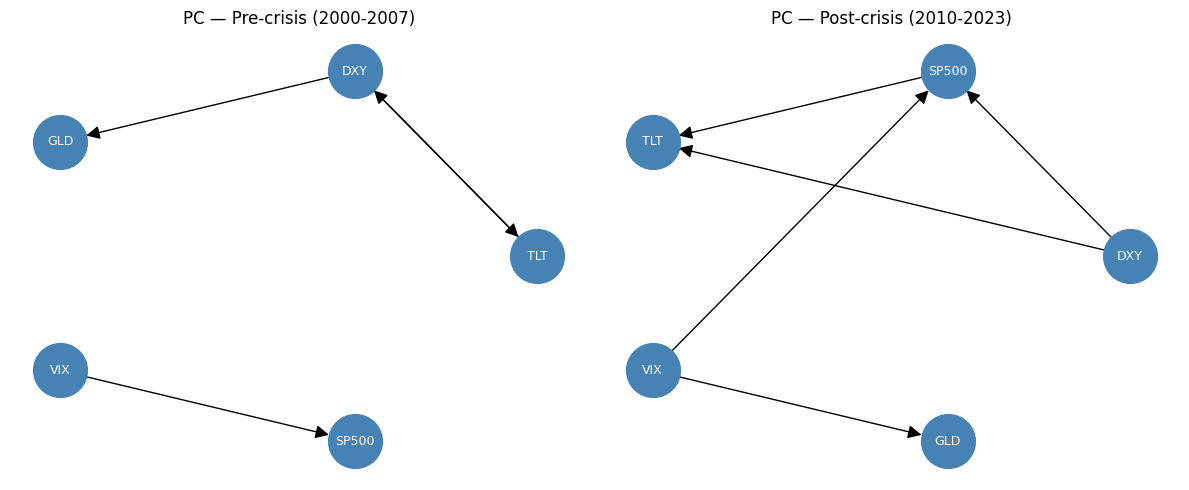

Aristas pre-crisis:  [('TLT', 'DXY'), ('DXY', 'TLT'), ('DXY', 'GLD'), ('VIX', 'SP500')]
Aristas post-crisis: [('DXY', 'SP500'), ('DXY', 'TLT'), ('SP500', 'TLT'), ('VIX', 'GLD'), ('VIX', 'SP500')]


In [16]:
ret_pre  = returns.loc['2000-01-01':'2007-12-31']
ret_post = returns.loc['2010-01-01':'2023-12-31']

dag_pre  = PC(data=ret_pre ).estimate(variant='stable', ci_test='pearsonr', significance_level=0.05)
dag_post = PC(data=ret_post).estimate(variant='stable', ci_test='pearsonr', significance_level=0.05)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
draw_dag(dag_pre,  'PC — Pre-crisis (2000-2007)',  axes[0])
draw_dag(dag_post, 'PC — Post-crisis (2010-2023)', axes[1])
plt.tight_layout()
plt.show()

print('Aristas pre-crisis: ', list(dag_pre.edges()))
print('Aristas post-crisis:', list(dag_post.edges()))

## 6b. Comparacion Bull vs Bear Market

Extiende la variacion temporal: mercado alcista (2013-2017) vs crisis subprime (2007-2009).
Hipotesis: en mercados bajistas los grafos son mas densos (activos correlacionados bajo estres sistemico).

Working for n conditional variables: 4: 100%|██████████| 5/5 [00:00<00:00, 136.35it/s]


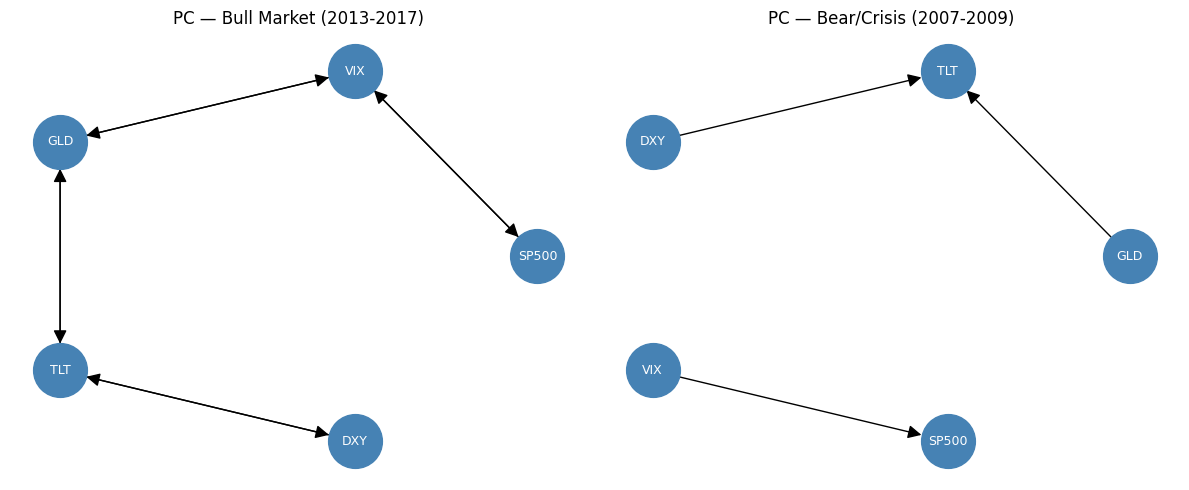

Bull: [('SP500', 'VIX'), ('VIX', 'GLD'), ('VIX', 'SP500'), ('GLD', 'VIX'), ('GLD', 'TLT'), ('TLT', 'GLD'), ('TLT', 'DXY'), ('DXY', 'TLT')]
Bear: [('GLD', 'TLT'), ('DXY', 'TLT'), ('VIX', 'SP500')]


In [17]:
ret_bull = returns.loc['2013-01-01':'2017-12-31']
ret_bear = returns.loc['2007-01-01':'2009-12-31']

dag_bull = PC(data=ret_bull).estimate(variant='stable', ci_test='pearsonr', significance_level=0.05)
dag_bear = PC(data=ret_bear).estimate(variant='stable', ci_test='pearsonr', significance_level=0.05)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
draw_dag(dag_bull, 'PC — Bull Market (2013-2017)', axes[0])
draw_dag(dag_bear, 'PC — Bear/Crisis (2007-2009)', axes[1])
plt.tight_layout(); plt.show()
print('Bull:', list(dag_bull.edges()))
print('Bear:', list(dag_bear.edges()))

## 7. Variacion 2 — PC vs HillClimbSearch

**PC** elimina aristas por tests de independencia condicional (constraint-based).  
**HillClimbSearch** maximiza el BIC Gaussiano de forma greedy (score-based).  
Dos enfoques validos que pueden producir grafos distintos sobre los mismos datos.

  0%|          | 7/1000000 [00:00<8:31:08, 32.61it/s] 


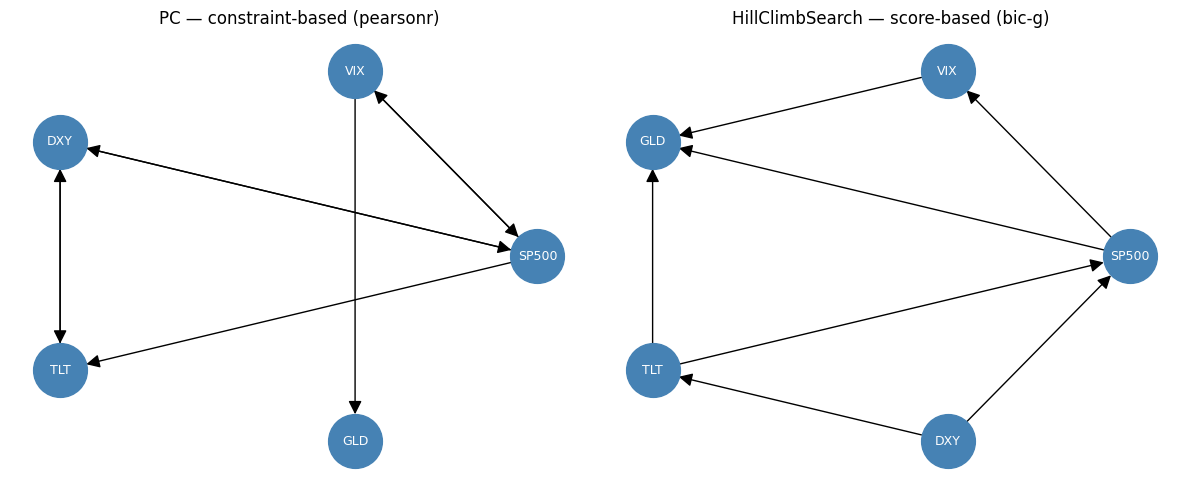

Aristas PC : [('SP500', 'VIX'), ('SP500', 'DXY'), ('SP500', 'TLT'), ('VIX', 'GLD'), ('VIX', 'SP500'), ('DXY', 'SP500'), ('DXY', 'TLT'), ('TLT', 'DXY')]
Aristas HCS: [('SP500', 'VIX'), ('SP500', 'GLD'), ('VIX', 'GLD'), ('TLT', 'GLD'), ('TLT', 'SP500'), ('DXY', 'TLT'), ('DXY', 'SP500')]


In [18]:
dag_hcs = HillClimbSearch(data=returns).estimate(scoring_method='bic-g')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
draw_dag(dag_pc,  'PC — constraint-based (pearsonr)',      axes[0])
draw_dag(dag_hcs, 'HillClimbSearch — score-based (bic-g)', axes[1])
plt.tight_layout()
plt.show()

print('Aristas PC :', list(dag_pc.edges()))
print('Aristas HCS:', list(dag_hcs.edges()))

## 8. Causalidad de Granger — p-values por pares

El test de Granger pregunta: el pasado de X ayuda a predecir Y mejor que el pasado de Y solo?
p < 0.05 (celda roja) indica precedencia temporal significativa. maxlag=5 dias de negociacion.

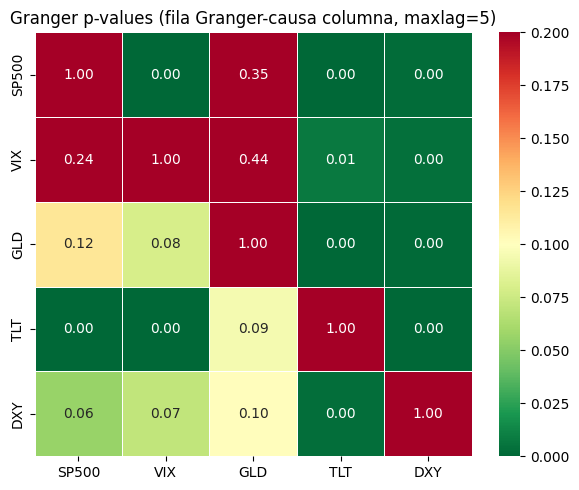

In [19]:
cols = returns.columns.tolist()
pval = pd.DataFrame(np.ones((5, 5)), index=cols, columns=cols)
for r in cols:
    for c in cols:
        if r != c:
            res = grangercausalitytests(returns[[r, c]], maxlag=5, verbose=False)
            pval.loc[r, c] = min(res[lag][0]['ssr_ftest'][1] for lag in res)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(pval, annot=True, fmt='.2f', cmap='RdYlGn_r', vmin=0, vmax=0.2,
            ax=ax, linewidths=0.5)
ax.set_title('Granger p-values (fila Granger-causa columna, maxlag=5)')
plt.tight_layout(); plt.show()

## 9. PC con retardos (lag-1)

Anadimos las variables retardadas un dia y ejecutamos PC sobre las 10 columnas.
Una arista X_lag1 -> Y indica causalidad temporal: el pasado de X precede a Y.

Working for n conditional variables: 5: 100%|██████████| 5/5 [00:00<00:00,  5.95it/s]


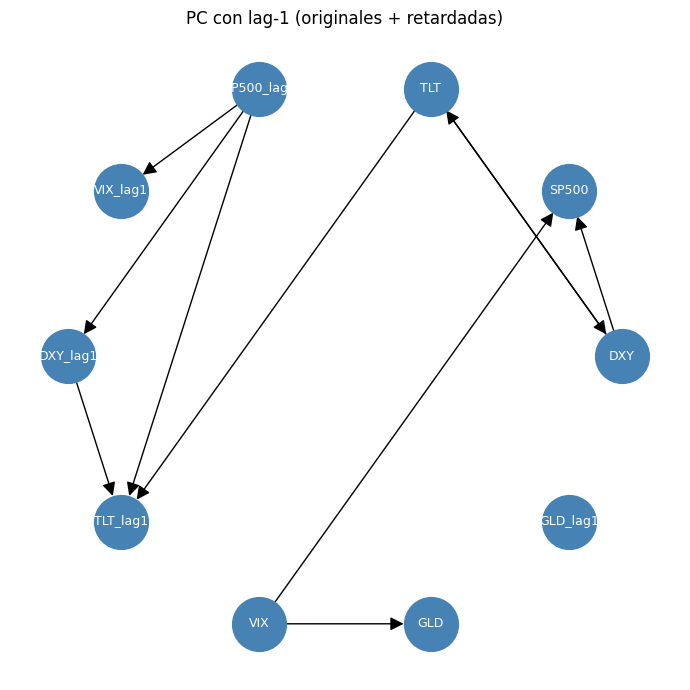

Aristas lag: [('DXY', 'SP500'), ('DXY', 'TLT'), ('SP500_lag1', 'VIX_lag1'), ('SP500_lag1', 'DXY_lag1'), ('SP500_lag1', 'TLT_lag1'), ('VIX', 'GLD'), ('VIX', 'SP500'), ('DXY_lag1', 'TLT_lag1'), ('TLT', 'DXY'), ('TLT', 'TLT_lag1')]


In [20]:
lagged = returns.copy()
for col in returns.columns:
    lagged[col + '_lag1'] = returns[col].shift(1)
lagged = lagged.dropna()

dag_lag = PC(data=lagged).estimate(variant='stable', ci_test='pearsonr', significance_level=0.05)

fig, ax = plt.subplots(figsize=(7, 7))
draw_dag(dag_lag, 'PC con lag-1 (originales + retardadas)', ax)
plt.tight_layout(); plt.show()
print('Aristas lag:', list(dag_lag.edges()))

## 10. Algoritmo LiNGAM — comparacion con PC

LiNGAM (Linear Non-Gaussian Acyclic Model) usa ICA en lugar de tests de independencia.
Identifica un DAG completamente orientado aprovechando que los retornos tienen colas gordas (no gaussianos).

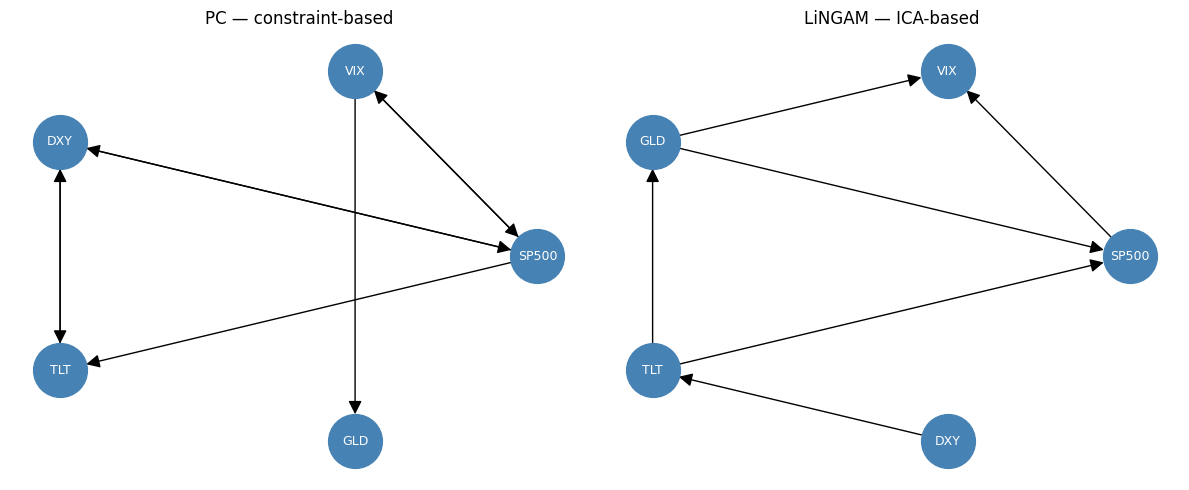

In [21]:
model_ling = lingam.DirectLiNGAM()
model_ling.fit(returns.values)
adj_l = pd.DataFrame(model_ling.adjacency_matrix_, index=returns.columns, columns=returns.columns)

G_l = nx.DiGraph()
G_l.add_nodes_from(returns.columns)
for i, src in enumerate(returns.columns):
    for j, tgt in enumerate(returns.columns):
        if abs(adj_l.iloc[j, i]) > 0.05:
            G_l.add_edge(src, tgt)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
draw_dag(dag_pc, 'PC — constraint-based', axes[0])
pos = nx.circular_layout(G_l)
nx.draw_networkx(G_l, pos, ax=axes[1], node_color='steelblue', node_size=1500,
                 font_color='white', edge_color='black', arrows=True, arrowsize=20, font_size=9)
axes[1].set_title('LiNGAM — ICA-based'); axes[1].axis('off')
plt.tight_layout(); plt.show()

## 11. Sensibilidad al parametro alpha (PC)

Alpha alto = menos estricto = mas aristas en el grafo.
Barremos [0.01, 0.05, 0.10, 0.20] para ver si las conclusiones son robustas al parametro elegido.

Working for n conditional variables: 4: 100%|██████████| 5/5 [00:00<00:00, 34.68it/s] 


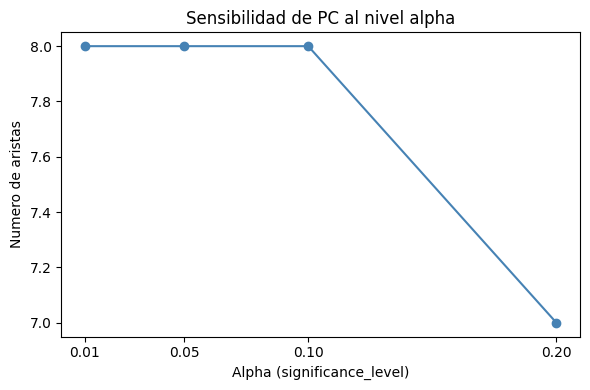

{0.01: 8, 0.05: 8, 0.1: 8, 0.2: 7}


In [22]:
alphas = [0.01, 0.05, 0.10, 0.20]
n_edges = [len(list(PC(data=returns).estimate(variant='stable', ci_test='pearsonr',
           significance_level=a).edges())) for a in alphas]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(alphas, n_edges, marker='o', color='steelblue')
ax.set_xlabel('Alpha (significance_level)'); ax.set_ylabel('Numero de aristas')
ax.set_title('Sensibilidad de PC al nivel alpha')
ax.set_xticks(alphas)
plt.tight_layout(); plt.show()
print(dict(zip(alphas, n_edges)))

## 12. Estabilidad por bootstrap (semilla np.random.seed=42)

PC se ejecuta 20 veces sobre muestras bootstrap (resampleo con reemplazo).
La frecuencia de cada arista mide su robustez: 1.0 = aparece siempre, 0.0 = nunca.

Working for n conditional variables: 4: 100%|██████████| 5/5 [00:00<00:00, 69.86it/s]


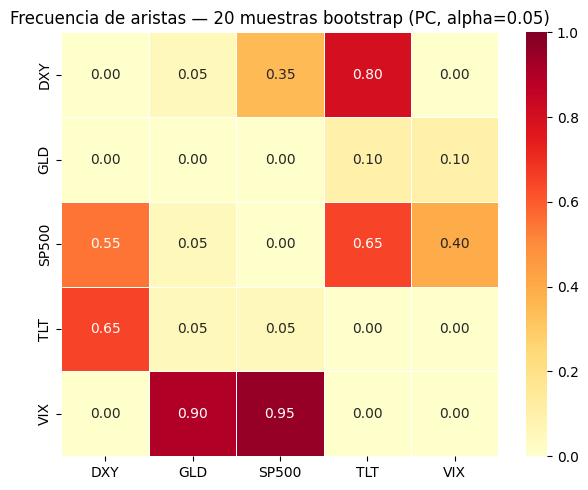

In [23]:
nodes = sorted(returns.columns)
edge_counts = pd.DataFrame(0, index=nodes, columns=nodes)
np.random.seed(42)
n_boot = 20

for _ in range(n_boot):
    s = returns.sample(frac=1.0, replace=True)
    d = PC(data=s).estimate(variant='stable', ci_test='pearsonr', significance_level=0.05)
    for u, v in d.edges():
        edge_counts.loc[u, v] += 1

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(edge_counts / n_boot, annot=True, fmt='.2f', cmap='YlOrRd',
            vmin=0, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Frecuencia de aristas — 20 muestras bootstrap (PC, alpha=0.05)')
plt.tight_layout(); plt.show()

## 13. Visualizacion interactiva con pyvis

Genera un HTML interactivo donde los nodos se arrastran y hay zoom.
El archivo dag_pc_interactivo.html puede abrirse en cualquier navegador sin Python.

In [24]:
net = Network(height='500px', width='100%', directed=True, notebook=True)
for node in dag_pc.nodes():
    net.add_node(node, label=node, color='steelblue')
for u, v in dag_pc.edges():
    net.add_edge(u, v, arrows='to')

net.write_html('dag_pc_interactivo.html')
from IPython.display import IFrame
IFrame('dag_pc_interactivo.html', width=700, height=520)

## 14. EXTRA — Factor Mirage: sesgo de colisionador

Un **colisionador** `A -> C <- B` bloquea el camino entre A y B.  
Controlar por C en una regresion **abre** ese camino y crea correlacion espuria.  
El DAG revela si DXY es colisionador — si lo es, incluirlo en la regresion es un error estadistico.

Estructura causal — PC (2000-2024):
  SP500 -> VIX
  SP500 -> DXY
  SP500 -> TLT
  VIX -> GLD
  VIX -> SP500
  DXY -> SP500
  DXY -> TLT
  TLT -> DXY

Coeficiente GLD sin DXY : -0.0321
Coeficiente GLD con DXY : -0.0477
Diferencia              : -0.0156


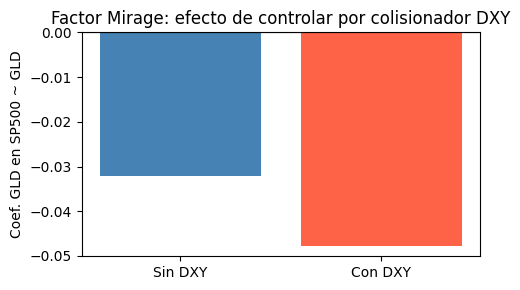

In [25]:
# Inspeccionar estructura del DAG para identificar colisionadores
print('Estructura causal — PC (2000-2024):')
for e in dag_pc.edges():
    print(f'  {e[0]} -> {e[1]}')

# Regresion SP500 ~ GLD  sin controlar por DXY
coef_sin = LinearRegression().fit(returns[['GLD']], returns['SP500']).coef_[0]

# Regresion SP500 ~ GLD + DXY  (controlando por posible colisionador)
coef_con = LinearRegression().fit(returns[['GLD', 'DXY']], returns['SP500']).coef_[0]

print(f'\nCoeficiente GLD sin DXY : {coef_sin:.4f}')
print(f'Coeficiente GLD con DXY : {coef_con:.4f}')
print(f'Diferencia              : {coef_con - coef_sin:.4f}')

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(['Sin DXY', 'Con DXY'], [coef_sin, coef_con], color=['steelblue', 'tomato'])
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Coef. GLD en SP500 ~ GLD')
ax.set_title('Factor Mirage: efecto de controlar por colisionador DXY')
plt.tight_layout()
plt.show()